# Quick start guide

This notebook provides minimal code snippets to illustrate the main functionlity of `SNuDD`.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy
import matplotlib.pyplot as plt

## Define an NSI model

In [2]:
from snudd.models import GeneralNSI

# Define NSI parameters
NSI_matrix = numpy.array([[0.0, 0.0, 0.0],
                          [0.0, 0.0, 0.1],
                          [0.0, 0.1, 0.0]])
NSI_eta = numpy.pi/4
NSI_phi = 0

# Create NSI model object
NSI_model = GeneralNSI(NSI_matrix, NSI_eta, NSI_phi)

## Compute neutrino density matrix

### Only solar density matrix

In [3]:
from snudd.nsi.nsi_probabilities import DensityMatrixCalculator

# Create probability calculator 
NSI_density_calculator = DensityMatrixCalculator(NSI_model)

# Calculate solar density matrix over neutrino energy range
Enus = numpy.geomspace(1e-6, 1e0, 200) # in GeV
solar_density = NSI_density_calculator.density(Enus, '8B')

# Returns an array of 3x3 density matrices evaluated over the Enus
numpy.shape(solar_density)

(200, 3, 3)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

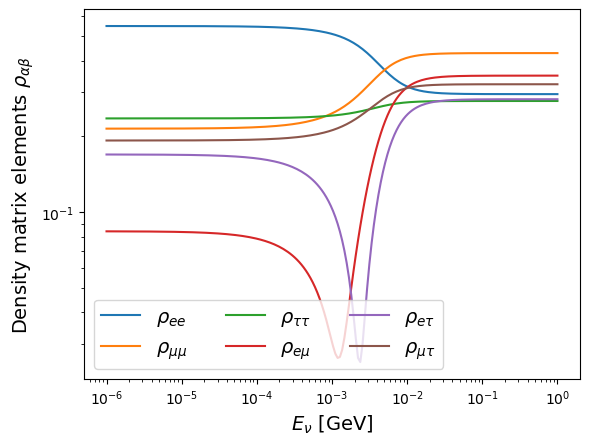

In [4]:
plt.loglog(Enus, abs(solar_density[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(Enus, abs(solar_density[:, 1,1]),  label=r'$\rho_{\mu\mu}$')
plt.loglog(Enus, abs(solar_density[:, 2,2]),  label=r'$\rho_{\tau\tau}$')
plt.loglog(Enus, abs(solar_density[:, 0,1]),  label=r'$\rho_{e\mu}$')
plt.loglog(Enus, abs(solar_density[:, 0,2]),  label=r'$\rho_{e\tau}$')
plt.loglog(Enus, abs(solar_density[:, 1,2]),  label=r'$\rho_{\mu\tau}$')

plt.legend(fontsize=14, ncol=3)

plt.ylabel(r'Density matrix elements $\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

### Combined solar + earth matter density matrix

In [5]:
from snudd.nsi.nsi_probabilities import DensityMatrixEarthCalculator

# Create probability calculator 
NSI_earth_calculator = DensityMatrixEarthCalculator(NSI_model)

# Calculate solar density matrix over neutrino energy range
Enus = numpy.geomspace(1e-6, 1e0, 200) # in GeV
cnadir = numpy.cos(numpy.pi/4)
earth_density = NSI_earth_calculator.density_earth(Enus, [cnadir], [1], nu='8B')

# Returns an array of 3x3 denisty matrices evaluated over the Enus
numpy.shape(earth_density)

(200, 3, 3)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

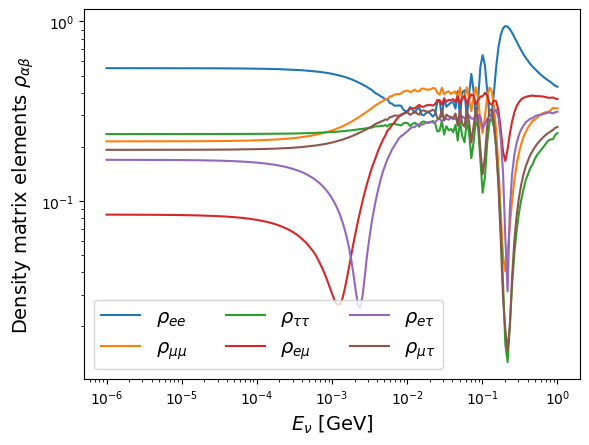

In [6]:
plt.loglog(Enus, abs(earth_density[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(Enus, abs(earth_density[:, 1,1]),  label=r'$\rho_{\mu\mu}$')
plt.loglog(Enus, abs(earth_density[:, 2,2]),  label=r'$\rho_{\tau\tau}$')
plt.loglog(Enus, abs(earth_density[:, 0,1]),  label=r'$\rho_{e\mu}$')
plt.loglog(Enus, abs(earth_density[:, 0,2]),  label=r'$\rho_{e\tau}$')
plt.loglog(Enus, abs(earth_density[:, 1,2]),  label=r'$\rho_{\mu\tau}$')

plt.legend(fontsize=14, ncol=3)

plt.ylabel(r'Density matrix elements $\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

## Nuclear recoil spectrum

In [50]:
from snudd import config
from snudd.targets import Nucleus

# Create scattering target
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 

# Load NSI model in scattering target and generate denisty matrix
Xe_nucleus.update_model(NSI_model)
Xe_nucleus.prepare_density() 
# Xe_nucleus.prepare_density(cnadirs=[1, 0.5, 0], cnadir_weights=[0.25, 0.5, 0.25]) # Uncomment to include earth matter effects with 3 different trajectories through the Earth.

# Compute recoil spectrum
E_Rs = numpy.geomspace(1e-2, 1e2, 500) / 1e6  # Recoil Energy in GeV
NSI_spec_nr = Xe_nucleus.spectrum(E_Rs)

Text(0.5, 0, '$E_{R}\\,\\,\\left[{\\rm keV}\\right]$')

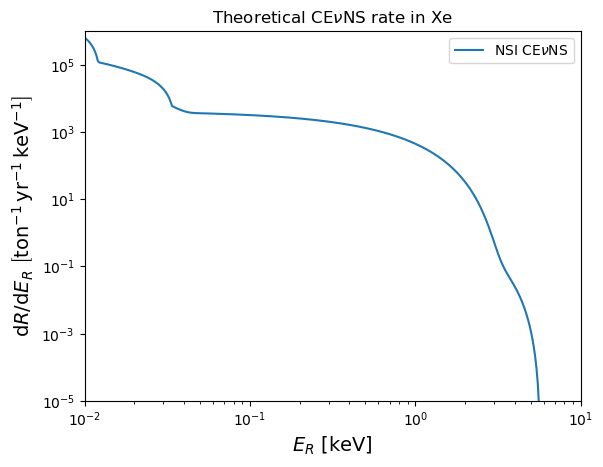

In [51]:
E_Rs_keV = E_Rs * 1e6 # Recoil Energy in keV for plotting
plt.loglog(E_Rs_keV, NSI_spec_nr, label=r"NSI CE$\nu$NS") 

plt.xlim(xmin=1e-2, xmax=1e1)
plt.ylim(ymax=1e6, ymin=1e-5)

plt.legend()
plt.title(r"Theoretical CE$\nu$NS rate in Xe")
plt.ylabel(r'${\rm d}R/{\rm d}E_R\,\,\left[{\rm ton}^{-1}\,{\rm yr}^{-1}\,{\rm keV}^{-1}\right]$', size=14)
plt.xlabel(r'$E_{R}\,\,\left[{\rm keV}\right]$', size=14)

## Electron recoil spectrum

In [52]:
from snudd import config
from snudd.targets import Nucleus, Electron   # still requires the host nucleus
from snudd.binding import binding_xe          # dataclass of binding energy data of xenon 
from snudd.rrpa    import rrpa_scaling        # ad-hoc rrpa scaling for bound electron

# Create host nucleus
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 

# Create bound electron object
Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling) 
Xe_electron.update_model(NSI_model)
Xe_electron.prepare_density()

# Compute recoil spectrum
E_Rs = numpy.geomspace(1e-2, 1e2, 500) / 1e6  # Recoil Energy in GeV
NSI_spec_er = Xe_electron.spectrum(E_Rs)

Text(0.5, 0, '$E_{R}\\,\\,\\left[{\\rm keV}\\right]$')

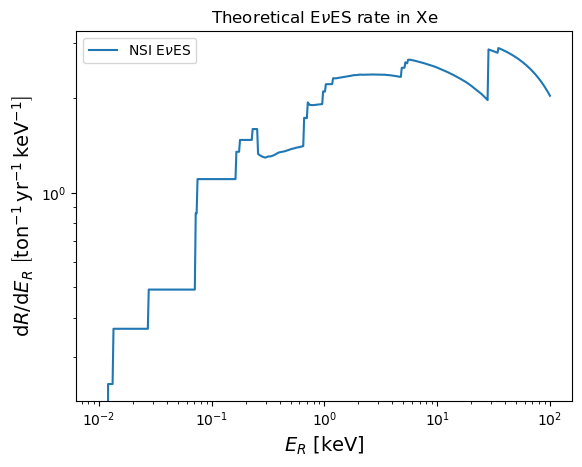

In [54]:
E_Rs_keV = E_Rs * 1e6 # Recoil Energy in keV for plotting
plt.loglog(E_Rs_keV, NSI_spec_er, label=r"NSI E$\nu$ES")


plt.legend()
plt.title(r"Theoretical E$\nu$ES rate in Xe")
plt.ylabel(r'${\rm d}R/{\rm d}E_R\,\,\left[{\rm ton}^{-1}\,{\rm yr}^{-1}\,{\rm keV}^{-1}\right]$', size=14)
plt.xlabel(r'$E_{R}\,\,\left[{\rm keV}\right]$', size=14)